# Open methods

Another class of root finding algorithms does not require bracketting, and is therefore deemed *open*. This alleviates the issue of N-D dimensionalization at the expense of robustness. They are usually faster than bracketting methods since we are not constantly updating the brackets, but our method is now succeptible to divergence which encroaches on the concept of a *well behaved* function.  

## Secant method

Let's reconsider the method of False Position but now we always disregard bracket updating and simply take $c$ as our new guess. Our algorithm is now:

> Take 2 initial guesses: $x^i$
>
> Calculate the next guess:

$$x^{i+1} = {x^i} - f(x^{i}) \frac{x^i-x^{i-1}}{f(x^i)-f(x^{i-1})} $$

> Check if tolerance is met

(Which tolerance?)

Iteration 0: x = 2
Iteration 1: x = 1.3333333333333335
Iteration 2: x = 1.4000000000000001
Iteration 3: x = 1.4146341463414633
Iteration 4: x = 1.41421143847487
Iteration 5: x = 1.4142135620573204
Approximate root: 1.4142135620573204

The sequence of errors is:
Iteration,  0  error in x is  0.4142135620573204
Iteration,  1  error in x is  0.5857864379426796
Iteration,  2  error in x is  0.08088022872398692
Iteration,  3  error in x is  0.014213562057320273
Iteration,  4  error in x is  0.00042058428414293303
Iteration,  5  error in x is  2.12358245033073e-06
Iteration,  6  error in x is  0.0


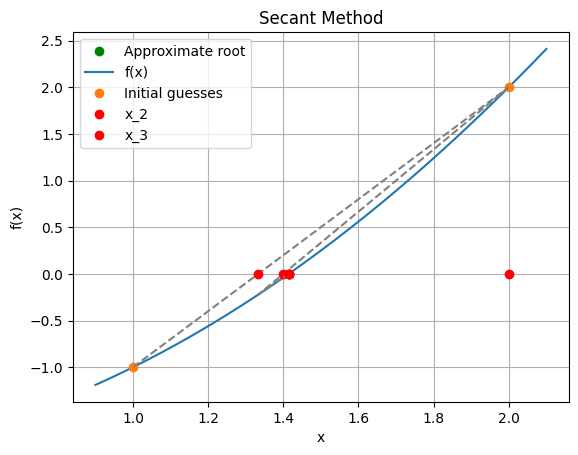

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def f(x):
  return x**2 - 2

def secant_method(f, x0, x1, tolerance=1e-6, max_iterations=100):
  """
  Finds the root of a function using the secant method.

  Args:
    f: The function to find the root of.
    x0: The initial guess.
    x1: The second initial guess.
    tolerance: The desired tolerance for the root.
    max_iterations: The maximum number of iterations.

  Returns:
    The approximate root of the function.
  """
  print(f"Iteration 0: x = {x1}")
  x_values = [x0, x1]
  for i in range(max_iterations):
    x_new = x1 - f(x1) * (x1 - x0) / (f(x1) - f(x0))
    x_values.append(x_new)
    print(f"Iteration {i+1}: x = {x_new}")
    if abs(f(x_new)) < tolerance:
      return x_new, x_values
    x0 = x1
    x1 = x_new
  return None, x_values

# Initial guesses
x0 = 1
x1 = 2

# Find the root using the secant method
root, x_values = secant_method(f, x0, x1)


if root:
    print("Approximate root:", root)
    plt.plot(root, 0, 'go', label='Approximate root')
else:
    print("Secant method did not converge within the maximum number of iterations.")

error = abs(np.array(x_values)-root)
print("\nThe sequence of errors is:")
for i,e in enumerate(error):
  print('Iteration, ', i, ' error in x is ', e)


# Plot the function and the secant method iterations
x = np.linspace(.9, 2.1, 100)
plt.plot(x, f(x), label='f(x)')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Secant Method')
plt.grid(True)

# Plot the initial guesses
plt.plot([x0, x1], [f(x0), f(x1)], 'o', label='Initial guesses')

# Plot each iteration of the secant method
for i in range(len(x_values) - 1):
    plt.plot([x_values[i], x_values[i+1]], [f(x_values[i]), f(x_values[i+1])], '--', color='gray')
    plt.plot(x_values[i+1], 0, 'ro', label=f'x_{i+2}' if i < 2 else None)


plt.legend()
plt.show()


The Secant method maintains superlinear convergence
...
but we can do better with a little more information...

## The Newton-Raphson method

Take another look at the fraction in the Secant method update equation:

$$x^{i+1} = {x^i} - f(x^{i}) \frac{x^i-x^{i-1}}{f(x^i)-f(x^{i-1})} $$

This is an (inverse) approximation of $\frac{\partial f}{\partial x}$, the derivative of $f$! Typically, we are able to find this quantity, and the algorithm becomes:



$$ x^{i+1} = {x^i} - \frac{f(x^{i})}{f'(x^i)} $$

or, solving for the increment $\Delta x = x^{i+1}-x^i$ and dropping the indicies,

$$ \begin{align}
\Delta x &= - \frac{f(x)}{f'(x)} \\
f'(x) \Delta x &= - f(x)
\end{align} $$

Iteration 0: x = 1
Iteration 1: x = 1.5
Iteration 2: x = 1.4166666666666667
Iteration 3: x = 1.4142156862745099
Iteration 4: x = 1.4142135623746899
Approximate root: 1.4142135623746899

The sequence of errors is:
Iteration,  0  error in x is  0.41421356237468987
Iteration,  1  error in x is  0.08578643762531013
Iteration,  2  error in x is  0.002453104291976871
Iteration,  3  error in x is  2.123899820016817e-06
Iteration,  4  error in x is  0.0


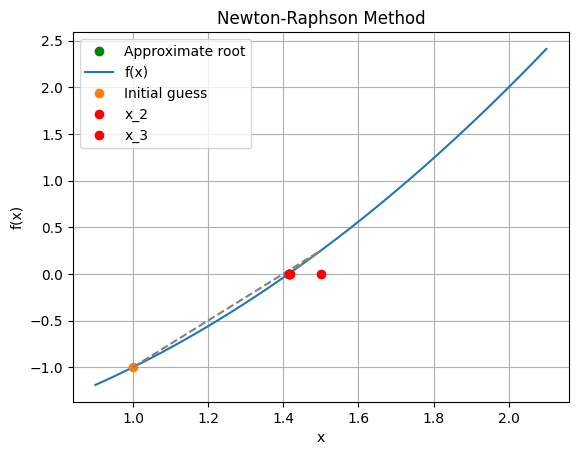

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def f(x):
  return x**2 - 2

def df(x):
  return 2*x

def newton_raphson(f, df, x0, tolerance=1e-6, max_iterations=100):
  """
  Finds the root of a function using the Newton-Raphson method.

  Args:
    f: The function to find the root of.
    df: The derivative of the function.
    x0: The initial guess.
    tolerance: The desired tolerance for the root.
    max_iterations: The maximum number of iterations.

  Returns:
    The approximate root of the function.
  """

  x_values = [x0]
  print(f"Iteration 0: x = {x0}")
  for i in range(max_iterations):
    x_new = x0 - f(x0) / df(x0)
    x_values.append(x_new)
    print(f"Iteration {i+1}: x = {x_new}")
    if abs(f(x_new)) < tolerance:
      return x_new, x_values
    x0 = x_new
  return None, x_values

# Initial guess
x0 = 1

# Find the root using the Newton-Raphson method
root, x_values = newton_raphson(f, df, x0)

if root:
    print("Approximate root:", root)
    plt.plot(root, 0, 'go', label='Approximate root')
else:
    print("Newton-Raphson method did not converge within the maximum number of iterations.")

error = abs(np.array(x_values)-root)
print("\nThe sequence of errors is:")
for i,e in enumerate(error):
  print('Iteration, ', i, ' error in x is ', e)


# Plot the function and the Newton-Raphson method iterations
x = np.linspace(.9, 2.1, 100)
plt.plot(x, f(x), label='f(x)')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Newton-Raphson Method')
plt.grid(True)

# Plot the initial guess
plt.plot([x0], [f(x0)], 'o', label='Initial guess')

# Plot each iteration of the Newton-Raphson method
for i in range(len(x_values) - 1):
    plt.plot([x_values[i], x_values[i+1]], [f(x_values[i]), f(x_values[i+1])], '--', color='gray')
    plt.plot(x_values[i+1], 0, 'ro', label=f'x_{i+2}' if i < 2 else None)


plt.legend()
plt.show()

The Newton-Raphson method has quadratic convergence ($k=2$) *near the root* which is a great result! It does so, however at the cost of calculating the Jacobian and solving a linear system.

In [ ]:
'''
!pip install Mint-NM
from Mint_NM import RootFinderOpen
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML, display
import ipywidgets as widgets
'''

In [ ]:
'''
# User Inputs Below:

# Function and derivative
f = lambda x: x**3 -27
fprime = lambda x: 3*x**2

# Initial Guess(es) and Specifications
x0 = 27.0
x1 = 25.0
tol = 1e-6
max_iter = 20

solver = RootFinderOpen(f=f, fprime=fprime, x0=x0, x1=x1, tol=tol, max_iter=max_iter)
solver.show_toggle_open(interval_ms=750)
'''

<iframe 
    src="https://themintlab.github.io/ENGPHYS_3NM4/Book/assets/Netwon_Secant.html" 
    width="800px" 
    height="750px" 
    frameborder="0"
    allowfullscreen>
</iframe>

In [ ]:
'''
# Function and derivative
f = lambda x: x**2 + 2
fprime = lambda x: 2*x

# Initial Guess(es) and Specifications
x0 = 5.0
x1 = 1.0
tol = 1e-6
max_iter = 15

solver = RootFinderOpen(f=f, fprime=fprime, x0=x0, x1=x1, tol=tol, max_iter=max_iter)
solver.show_toggle_open(interval_ms=750)
'''


<iframe 
    src="https://themintlab.github.io/ENGPHYS_3NM4/Book/assets/Newton_Secant_Unconverging_demo.html" 
    width="800px" 
    height="750px" 
    frameborder="0"
    allowfullscreen>
</iframe>